## Титульный лист

# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение (продвинутый уровень)  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic — Machine Learning from Disaster  
**Выполнил:** Мусаев Руслан Шамхалович  
**Группа:** ПКТб-23-1  
**Преподаватель:** Спирин Игорь Сергеевич  
**Репозиторий:** https://github.com/compl1ment/ml-course-musaev  
**Путь к работе:** `module-1-titanic/notebook.ipynb`  
**Дата:** 23.09.2026  
**Учебный год:** 2026/2027



## Введение

**Задача:** по данным пассажира определить, выжил он или нет. В столбце `Survived` значение 1 означает «выжил», 0 — «не выжил». Это классификация: у ответа всего два варианта. При регрессии мы предсказывали бы число, например стоимость билета.

Сначала посмотрим на данные и пропуски. Затем подготовим признаки, обучим модели и проверим их на части строк, которые не использовали при обучении. При заполнении пропусков нельзя брать статистику из проверочной части: так модель получит лишнюю информацию.

Главная метрика здесь — **ROC-AUC**. Она показывает, насколько хорошо модель ставит выживших выше невыживших по своей оценке шанса выживания. Ещё посмотрим Accuracy и F1: первая показывает общую долю верных ответов, а вторая учитывает ошибки при поиске выживших. Один показатель не расскажет обо всех ошибках.

Цель работы — изучить данные, сравнить как минимум две модели и сделать функцию для прогноза по данным нового пассажира. Попробуем получить ROC-AUC не ниже 0,80 на проверочной части.

## Теоретическая часть

**EDA — знакомство с данными.** Сначала нужно узнать, сколько в таблице строк и столбцов и что означает каждый столбец. Потом смотрим, где есть пропуски и какие значения встречаются чаще всего. Графики помогают увидеть то, что не всегда заметно в таблице чисел: например, как различается возраст пассажиров. После такого анализа проще решить, какие признаки брать в модель. Связь на графике сама по себе не доказывает причину.

**Пропуски.** Иногда возраст или другое значение не записали. Если выбросить все строки с неизвестным возрастом, данных станет намного меньше. Поэтому пустой `Age` заменяем медианой возраста пассажиров того же класса и пола. Медиана меньше зависит от очень больших или маленьких значений, чем среднее. Для двух пустых значений `Embarked` берём самый частый порт. Эти числа ищем только в обучающей части, а затем применяем и к проверочной.

**Категории и числа.** Модель не умеет напрямую работать со словами `male`, `female`, `C`, `Q`, `S`. `LabelEncoder` даёт полу коды: `female → 0`, `male → 1`. Здесь категорий две, поэтому такой код подходит. Для порта используем One-Hot: отдельные столбцы показывают, равен ли порт Q или S. Если оба равны нулю, порт — C. При прогнозе нового пассажира кодирование должно быть точно таким же.

**Масштабирование.** Возраст и стоимость билета измеряются в разных диапазонах. `StandardScaler` приводит признаки к общему масштабу: вычитает среднее и делит на стандартное отклонение. `MinMaxScaler` работает иначе — обычно переносит значения в диапазон от 0 до 1. Для Logistic Regression мы используем `StandardScaler`; дереву решений он не нужен. Среднее и отклонение считаем только на обучающих строках.

**Новые признаки.** Иногда из исходных столбцов можно получить полезную информацию. `Family_Size = SibSp + Parch + 1` — размер семьи на борту вместе с самим пассажиром. `Is_Alone` показывает, что пассажир ехал один. `Age_Group` делит людей на возрастные группы для анализа. Новые признаки могут быть связаны с исходными, поэтому отдельный коэффициент модели не всегда легко объяснить.

**Метрики.** В задаче есть четыре вида результата: верно найденные выжившие (TP), верно найденные невыжившие (TN), ошибочно названные выжившими (FP) и пропущенные выжившие (FN). Accuracy — доля всех верных ответов. Precision показывает, как часто прогноз «выжил» оказался верным. Recall показывает, сколько настоящих выживших модель нашла. F1 соединяет Precision и Recall в одно число. ROC-AUC оценивает порядок пассажиров по оценке шанса выживания при разных порогах.

| Метрика | Формула | Простой смысл |
|---|---|---|
| Accuracy | $(TP+TN)/(TP+TN+FP+FN)$ | Доля верных ответов |
| Precision | $TP/(TP+FP)$ | Точность ответа «выжил» |
| Recall / TPR | $TP/(TP+FN)$ | Доля найденных выживших |
| F1 | $2PR/(P+R)$ | Баланс Precision и Recall |
| FPR | $FP/(FP+TN)$ | Доля ложных ответов «выжил» |
| ROC-AUC | $\int_0^1 TPR(FPR)\,dFPR$ | Насколько хорошо выжившие стоят выше невыживших |

В формуле F1 буквы $P$ и $R$ означают Precision и Recall. Если в знаменателе получается ноль, код возвращает ноль благодаря `zero_division=0`.

## Описание данных

Данные взяты из [соревнования Kaggle Titanic](https://www.kaggle.com/competitions/titanic). Файлы лежат в `data/`; подробнее они описаны в [titanic_info.md](data/titanic_info.md). В `train.csv` 891 пассажир и 12 столбцов, включая ответ `Survived`. В `test.csv` 418 пассажиров, но ответов нет. Из 11 остальных столбцов шесть содержат числа или числовые коды, а пять — текст. `PassengerId` нужен для идентификации, но в модель его не добавляем.

| Столбец | Тип | Что означает | Пропуски в train |
|---|---|---|---:|
| PassengerId | int | Номер пассажира | 0 |
| Survived | int 0/1 | Выжил или нет | 0 |
| Pclass | int 1/2/3 | Класс билета | 0 |
| Name | str | Имя | 0 |
| Sex | str | Пол | 0 |
| Age | float | Возраст | 177 (19,9 %) |
| SibSp | int | Братья, сёстры и супруги | 0 |
| Parch | int | Родители и дети | 0 |
| Ticket | str | Номер билета | 0 |
| Fare | float | Цена билета | 0 |
| Cabin | str | Каюта | 687 (77,1 %) |
| Embarked | str | Порт посадки | 2 (0,2 %) |

Не выжили 549 пассажиров (61,6 %), выжили 342 (38,4 %). В `test.csv` не хватает 86 возрастов, 327 номеров кают и одной цены билета. `gender_submission.csv` показывает формат ответа для Kaggle; настоящие ответы для `test.csv` в нём не содержатся.

In [1]:
# Загружаем нужные библиотеки.
import json
import time
from io import BytesIO
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Пути считаются от папки модуля.
DATA_DIR = Path('data')
MODELS_DIR = Path('models')
EXAMPLES_DIR = Path('examples')
MODELS_DIR.mkdir(exist_ok=True)
EXAMPLES_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

# Читаем файлы и смотрим первые строки.
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')
print('Форма train/test:', train_df.shape, test_df.shape)
print('\nПервые строки train:')
display(train_df.head())
print('\nТипы и непустые значения:')
train_df.info()
print('\nОписательная статистика:')
display(train_df.describe(include='all').T)
print('\nДоли классов:')
display(train_df['Survived'].value_counts(normalize=True).sort_index().rename('share'))

Форма train/test: (891, 12) (418, 11)

Первые строки train:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Типы и непустые значения:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Описательная статистика:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292



Доли классов:


Survived
0    0.616162
1    0.383838
Name: share, dtype: float64

## Подготовка данных и EDA

Сначала смотрим исходные данные: пропуски, частоты категорий, асимметрию и эксцесс числовых столбцов. Затем строим графики для ответа, возраста, класса билета, пола, порта посадки и корреляций. Графики сохраняются в `examples/`.

Пропуски в train:


,missing
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Асимметрия и эксцесс числовых полей:


,skew,kurtosis
PassengerId,0.000000,-1.200000
Survived,0.478523,-1.775005
Pclass,-0.630548,-1.280015
Age,0.389108,0.178274
SibSp,3.695352,17.880420
Parch,2.749117,9.778125
Fare,4.787317,33.398141


Частоты Pclass, Sex, Embarked:
Pclass {3: 491, 1: 216, 2: 184}
Sex {'male': 577, 'female': 314}
Embarked {'S': 644, 'C': 168, 'Q': 77, nan: 2}


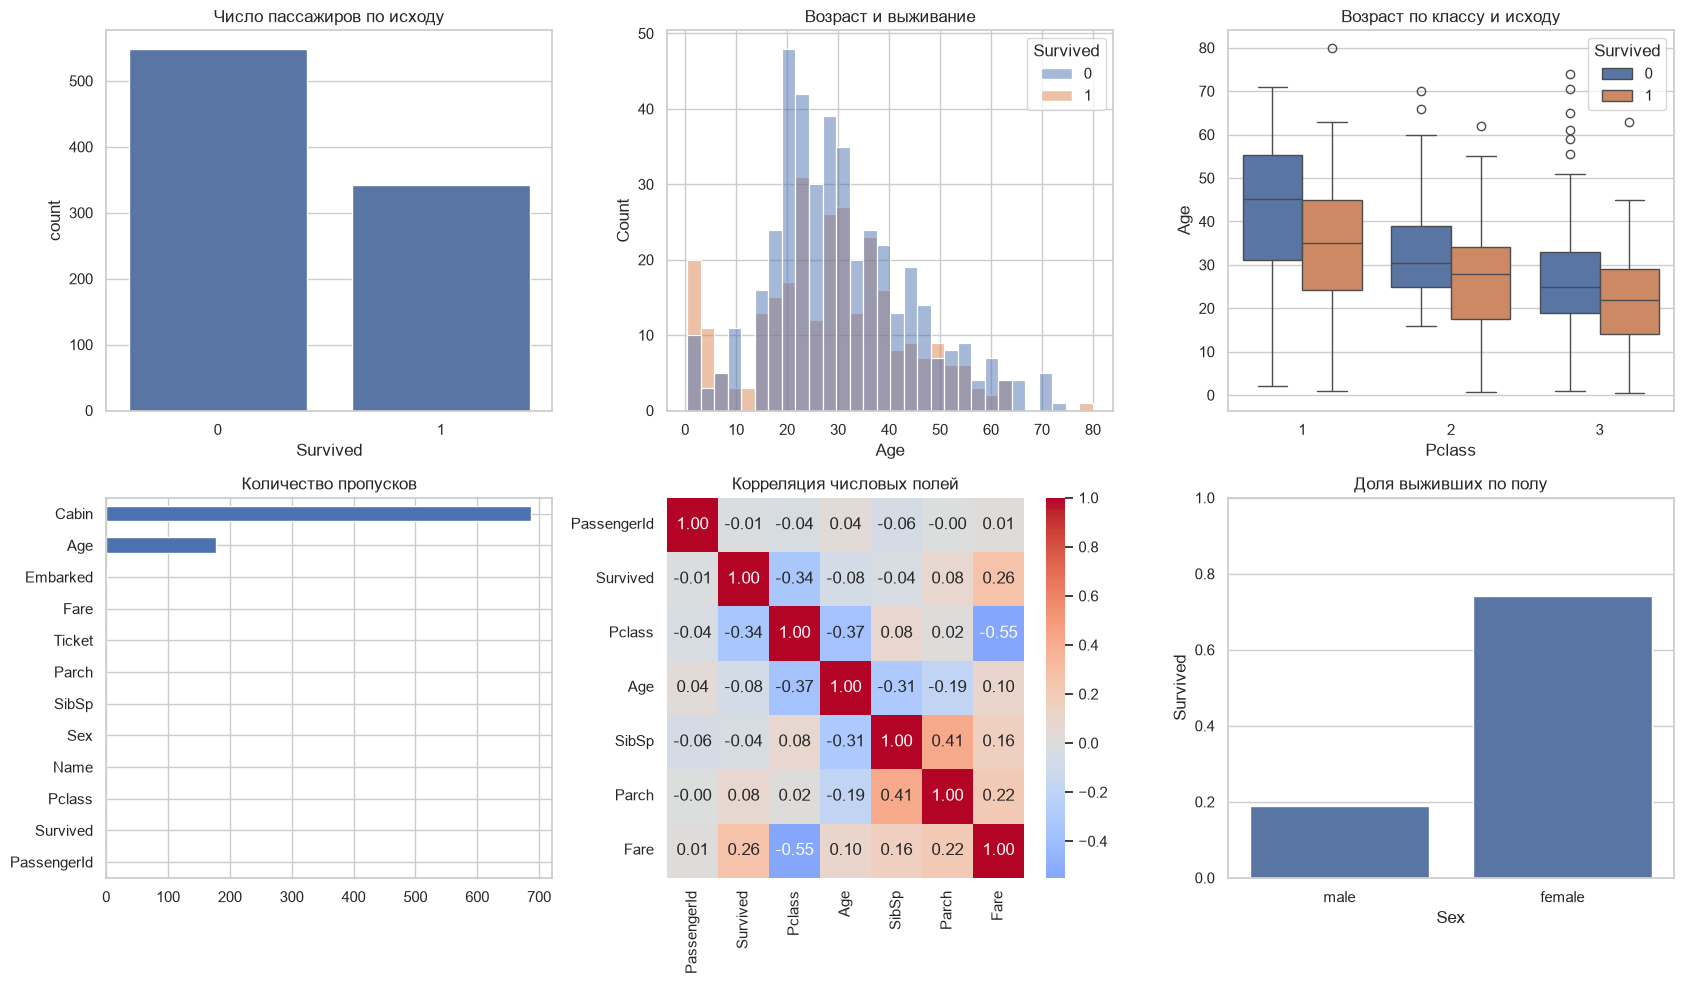

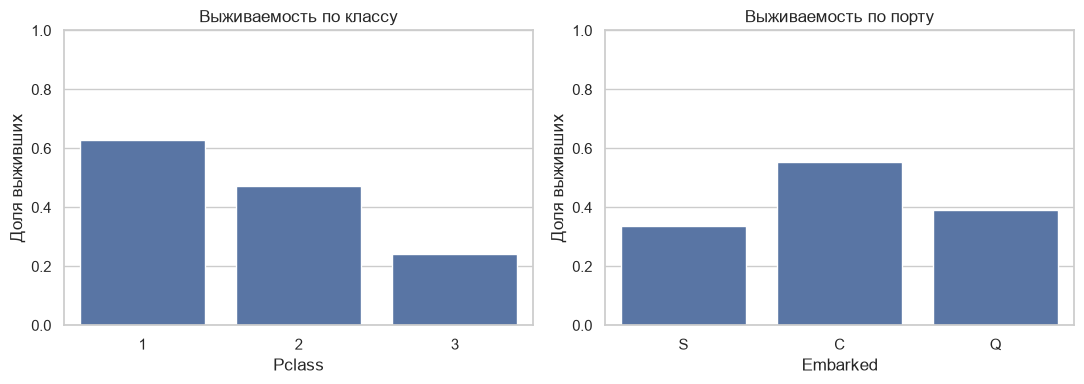

In [2]:
# Смотрим пропуски и распределения.
print('Пропуски в train:')
display(train_df.isna().sum().to_frame('missing'))
print('Асимметрия и эксцесс числовых полей:')
display(pd.DataFrame({'skew': train_df.select_dtypes('number').skew(),
                      'kurtosis': train_df.select_dtypes('number').kurtosis()}))
print('Частоты Pclass, Sex, Embarked:')
for column in ['Pclass', 'Sex', 'Embarked']:
    print(column, train_df[column].value_counts(dropna=False).to_dict())

# Строим основные графики.
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Число пассажиров по исходу')
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30,
             multiple='layer', ax=axes[0, 1])
axes[0, 1].set_title('Возраст и выживание')
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0, 2])
axes[0, 2].set_title('Возраст по классу и исходу')
train_df.isna().sum().sort_values().plot.barh(ax=axes[1, 0])
axes[1, 0].set_title('Количество пропусков')
sns.heatmap(train_df.select_dtypes('number').corr(), cmap='coolwarm',
            center=0, annot=True, fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Корреляция числовых полей')
sns.barplot(data=train_df, x='Sex', y='Survived', errorbar=None, ax=axes[1, 2])
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title('Доля выживших по полу')
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'eda_plots.png', dpi=160, bbox_inches='tight')
plt.show()

# Сравниваем классы и порты.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=train_df, x='Pclass', y='Survived', errorbar=None, ax=axes[0])
sns.barplot(data=train_df, x='Embarked', y='Survived', errorbar=None, ax=axes[1])
for ax, title in zip(axes, ['Выживаемость по классу', 'Выживаемость по порту']):
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel('Доля выживших')
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'survival_rates.png', dpi=160, bbox_inches='tight')
plt.show()

### Что видно на графиках

Возраст не указан примерно у каждого пятого пассажира. У `Cabin` пропусков ещё больше — около 77 %, поэтому этот столбец не используем. Выживаемость сильно различается по полу и классу билета. У `Fare` есть несколько очень больших значений. По порту посадки доли тоже различаются, но причина может быть в составе пассажиров, а не в самом порте.

**Как готовим данные:** пустой `Age` заполняем медианой по классу и полу, пустой `Embarked` — самым частым портом. Один пропуск `Fare` в `test.csv` заполняем медианой. Добавляем размер семьи, признак поездки в одиночку и возрастную группу. Пол кодируем через сохранённый `LabelEncoder`, порт — через One-Hot. Медианы, моду и кодировщик обучаем только после разделения данных.

In [3]:
# Запоминаем порядок признаков.
FEATURE_COLS = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

def fit_preprocessing(raw_train):
    # Берём медианы только из обучающей части.
    age_groups = raw_train.groupby(['Pclass', 'Sex'])['Age'].median()
    state = {
        'age_by_group': {f'{int(pclass)}|{sex}': float(age)
                         for (pclass, sex), age in age_groups.items()},
        'age_median': float(raw_train['Age'].median()),
        'fare_median': float(raw_train['Fare'].median()),
        'embarked_mode': str(raw_train['Embarked'].mode().iloc[0]),
    }
    encoder = LabelEncoder().fit(raw_train['Sex'])
    state['sex_mapping'] = {label: int(encoder.transform([label])[0])
                            for label in encoder.classes_}
    return state, encoder

def transform_passengers(raw, state, encoder):
    # Не меняем исходную таблицу.
    frame = raw.copy()
    missing_age = [state['age_by_group'].get(f'{int(pc)}|{sex}',
                                                 state['age_median'])
                   for pc, sex in zip(frame['Pclass'], frame['Sex'])]
    frame['Age'] = frame['Age'].fillna(pd.Series(missing_age, index=frame.index))
    frame['Age'] = frame['Age'].fillna(state['age_median'])
    frame['Fare'] = frame['Fare'].fillna(state['fare_median'])
    frame['Embarked'] = frame['Embarked'].fillna(state['embarked_mode'])
    frame = frame.drop(columns=['Cabin'], errors='ignore')

    # Проверяем пол и порт перед кодированием.
    if not frame['Sex'].isin(encoder.classes_).all():
        raise ValueError('Неизвестное значение Sex')
    if not frame['Embarked'].isin(['C', 'Q', 'S']).all():
        raise ValueError('Embarked должен быть C, Q или S')
    frame['Sex_Encoded'] = encoder.transform(frame['Sex'])

    # Добавляем одинаковые признаки во все выборки.
    frame['Family_Size'] = frame['SibSp'] + frame['Parch'] + 1
    frame['Is_Alone'] = (frame['Family_Size'] == 1).astype(int)
    frame['Age_Group'] = pd.cut(frame['Age'], bins=[0, 12, 18, 35, 60, np.inf],
                                labels=['Ребёнок', 'Подросток', 'Взрослый',
                                        'Средний', 'Пожилой'], include_lowest=True)
    port_columns = pd.get_dummies(frame['Embarked'], prefix='Embarked', dtype=int)
    frame['Embarked_Q'] = port_columns.reindex(columns=['Embarked_Q'],
                                              fill_value=0)['Embarked_Q']
    frame['Embarked_S'] = port_columns.reindex(columns=['Embarked_S'],
                                              fill_value=0)['Embarked_S']
    return frame[FEATURE_COLS].astype(float), frame

## Построение и обучение моделей

Делим `train.csv` на две части: 712 строк для обучения и 179 для проверки. Доля выживших в обеих частях примерно одинаковая. Для заполнения пропусков используем статистику только из первых 712 строк. `StandardScaler` тоже обучаем только на них.

Сравниваем три модели. Logistic Regression получает масштабированные признаки. Decision Tree и Random Forest работают с исходным масштабом. Random Forest добавлен для сравнения с деревом.

| Модель | Настройки | Масштабирование | Зачем сравниваем |
|---|---|---|---|
| Logistic Regression | `C=1`, `max_iter=1000` | Да | Простая базовая модель |
| Decision Tree | `max_depth=5`, `min_samples_leaf=2` | Нет | Проверяем нелинейные правила |
| Random Forest | 200 деревьев, `max_depth=6` | Нет | Сравниваем одно дерево с ансамблем |

In [4]:
# Сначала делим данные, потом считаем медианы.
raw_train, raw_valid = train_test_split(train_df, test_size=0.2,
                                        random_state=42, stratify=train_df['Survived'])
preprocessing_state, le_sex = fit_preprocessing(raw_train)
X_train, prepared_train = transform_passengers(raw_train, preprocessing_state, le_sex)
X_valid, prepared_valid = transform_passengers(raw_valid, preprocessing_state, le_sex)
y_train = raw_train['Survived']
y_valid = raw_valid['Survived']

# Обучаем scaler только на обучающей части.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
assert X_train.isna().sum().sum() == X_valid.isna().sum().sum() == 0
assert preprocessing_state['sex_mapping'] == {'female': 0, 'male': 1}
print('Размер train/validation:', X_train.shape, X_valid.shape)
print('Кодирование пола:', preprocessing_state['sex_mapping'])
print('Медианы Age по Pclass × Sex:', preprocessing_state['age_by_group'])

Размер train/validation: (712, 10) (179, 10)
Кодирование пола: {'female': 0, 'male': 1}
Медианы Age по Pclass × Sex: {'1|female': 35.0, '1|male': 40.0, '2|female': 29.0, '2|male': 30.0, '3|female': 21.5, '3|male': 26.0}


In [5]:
# Обучаем все модели на одних строках.
lr_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                                  min_samples_leaf=2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6,
                                  min_samples_leaf=2, random_state=42, n_jobs=-1)
models = {'logistic_regression': lr_model, 'decision_tree': dt_model,
          'random_forest': rf_model}
training_times = {}
for name, model in models.items():
    # Для LR берём масштабированные данные, для деревьев — обычные.
    matrix = X_train_scaled if name == 'logistic_regression' else X_train
    started = time.perf_counter()
    model.fit(matrix, y_train)
    training_times[name] = time.perf_counter() - started
    print(f'{name}: обучение {training_times[name]:.4f} с')

logistic_regression: обучение 0.0479 с
decision_tree: обучение 0.0368 с


random_forest: обучение 2.2379 с


## Оценка качества

Метрики считаем на 179 строках, которые модель не видела при обучении. Класс 1 — «выжил». ROC-AUC считаем по оценкам шанса выживания, а остальные метрики — по ответам 0 или 1. В Kaggle `test.csv` ответов нет, поэтому проверить качество на нём локально нельзя. Для каждой модели строим матрицу ошибок, а ROC-кривые показываем на одном графике.

,accuracy,precision,recall,f1,roc_auc,train_roc_auc,training_time_sec
logistic_regression,0.8045,0.7833,0.6812,0.7287,0.8489,0.8627,0.0479
random_forest,0.7877,0.8039,0.5942,0.6833,0.8457,0.9338,2.2379
decision_tree,0.7821,0.7419,0.6667,0.7023,0.8132,0.9069,0.0368



 logistic_regression 
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


 decision_tree 
               precision    recall  f1-score   support

           0       0.80      0.85      0.83       110
           1       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179


 random_forest 
               precision    recall  f1-score   support

           0       0.78      0.91      0.84       110
           1       0.80      0.59      0.68        69

    accuracy                           0.79       179
   macro avg       0.79      0.75      0.76       179
weighted avg  

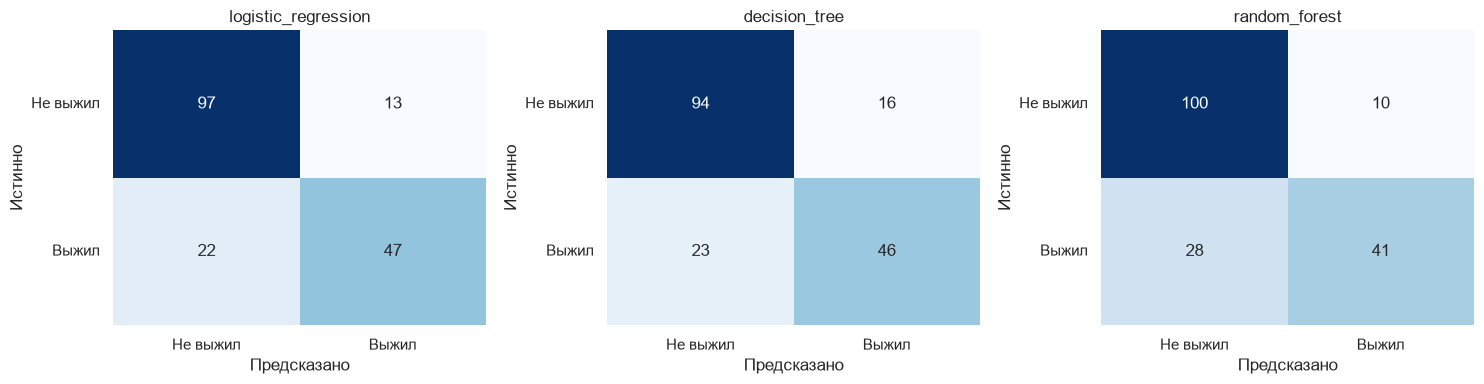

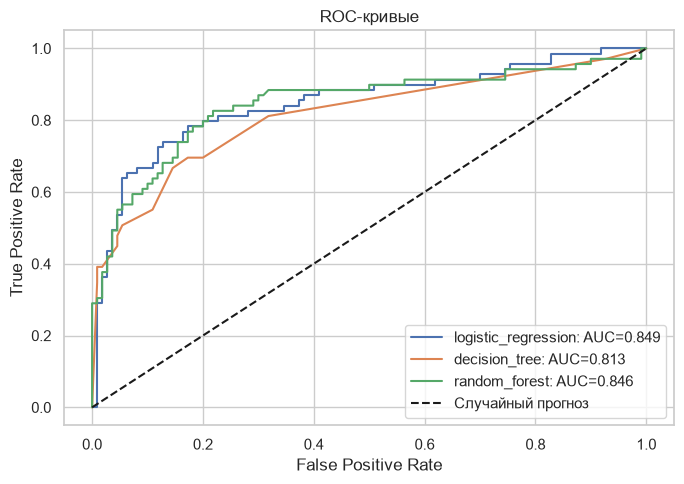

In [6]:
# Считаем метрики для каждой модели.
metrics = {}
predictions = {}
probabilities = {}
for name, model in models.items():
    matrix = X_valid_scaled if name == 'logistic_regression' else X_valid
    predictions[name] = model.predict(matrix)
    probabilities[name] = model.predict_proba(matrix)[:, 1]
    train_matrix = X_train_scaled if name == 'logistic_regression' else X_train
    metrics[name] = {
        'accuracy': float(accuracy_score(y_valid, predictions[name])),
        'precision': float(precision_score(y_valid, predictions[name], zero_division=0)),
        'recall': float(recall_score(y_valid, predictions[name], zero_division=0)),
        'f1': float(f1_score(y_valid, predictions[name], zero_division=0)),
        'roc_auc': float(roc_auc_score(y_valid, probabilities[name])),
        'train_roc_auc': float(roc_auc_score(y_train,
                                           model.predict_proba(train_matrix)[:, 1])),
        'training_time_sec': float(training_times[name]),
    }
metrics_table = pd.DataFrame(metrics).T.sort_values('roc_auc', ascending=False)
display(metrics_table.round(4))
for name in models:
    print('\n', name, '\n', classification_report(y_valid, predictions[name],
                                               zero_division=0))

# Показываем ошибки каждой модели.
fig, axes = plt.subplots(1, len(models), figsize=(15, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_valid, pred), annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=ax)
    ax.set(title=name, xlabel='Предсказано', ylabel='Истинно')
    ax.set_xticklabels(['Не выжил', 'Выжил'])
    ax.set_yticklabels(['Не выжил', 'Выжил'], rotation=0)
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

# Для ROC нужны оценки шанса, а не ответы 0/1.
fig, ax = plt.subplots(figsize=(7, 5))
for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_valid, proba)
    ax.plot(fpr, tpr, label=f"{name}: AUC={metrics[name]['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Случайный прогноз')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC-кривые')
ax.legend()
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'roc_curves.png', dpi=160, bbox_inches='tight')
plt.show()

### Сравнение моделей

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC проверка | ROC-AUC обучение | Время, с |
|---|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.804 | 0.783 | 0.681 | 0.729 | 0.849 | 0.863 | 0.0479 |
| Decision Tree | 0.782 | 0.742 | 0.667 | 0.702 | 0.813 | 0.907 | 0.0368 |
| Random Forest | 0.788 | 0.804 | 0.594 | 0.683 | 0.846 | 0.934 | 2.2379 |

По ROC-AUC Logistic Regression получила 0,849, Random Forest — 0,846, а Decision Tree — 0,813. Разница между первыми двумя всего 0,003, поэтому одного разбиения мало, чтобы уверенно назвать одну из них сильнее. У дерева ROC-AUC на обучении 0,907, а на проверке 0,813: вероятно, оно сильнее подстроилось под обучающие строки. Для более надёжного сравнения пригодилась бы кросс-валидация.

## Интерпретация результатов

У Logistic Regression у каждого признака есть коэффициент. Положительный коэффициент повышает оценку выживания, отрицательный — понижает. Но признаки перед обучением масштабировались, поэтому коэффициенты относятся к изменению на одно стандартное отклонение, а не на один год или один фунт. `SibSp`, `Parch` и `Family_Size` связаны между собой, так что читать каждый их коэффициент отдельно нужно осторожно.

У дерева другая мера — важность признака при разбиении строк. Она показывает, какие признаки дерево чаще использовало для решений. Эта важность не доказывает, что признак стал причиной выживания.

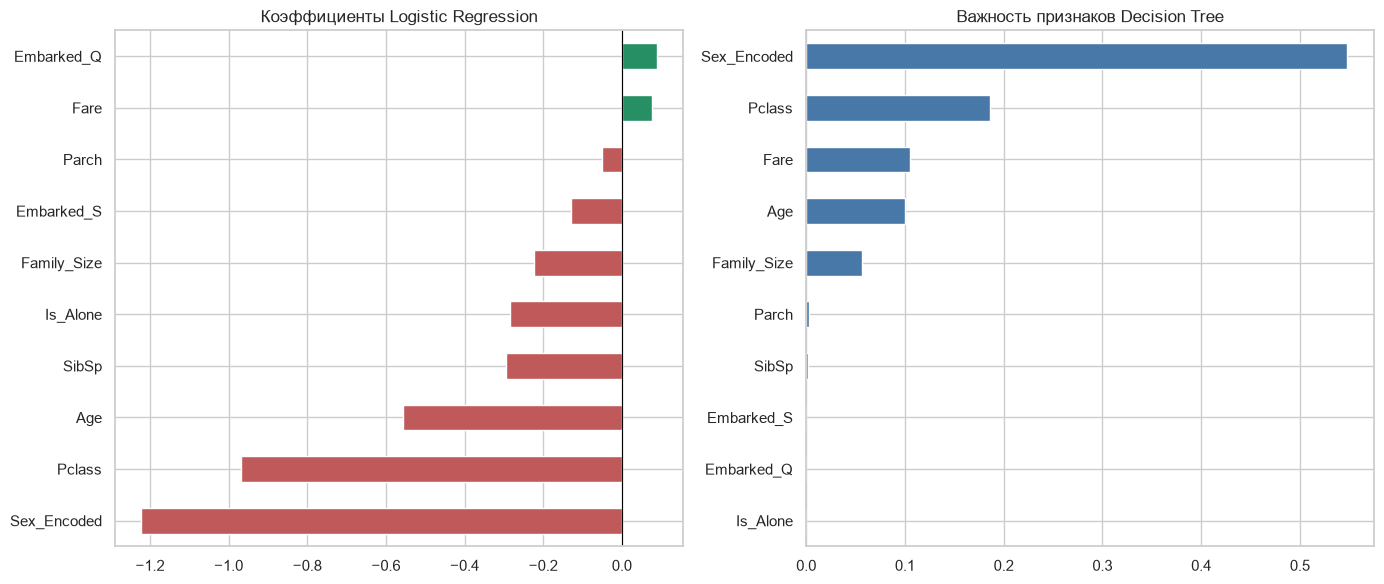

Положительные коэффициенты: {'Embarked_Q': 0.09, 'Fare': 0.078}
Три наиболее отрицательных коэффициента: {'Sex_Encoded': -1.223, 'Pclass': -0.968, 'Age': -0.556}
Три важнейших признака дерева: {'Sex_Encoded': 0.548, 'Pclass': 0.186, 'Fare': 0.105}
Доли выживших по полу: {'female': 0.742, 'male': 0.189}
Доли выживших по классу: {1: 0.63, 2: 0.473, 3: 0.242}
Доли выживших среди одиночек: {False: 0.506, True: 0.304}


In [7]:
# Смотрим коэффициенты LR и важность в дереве.
coefficients = pd.Series(lr_model.coef_[0], index=FEATURE_COLS).sort_values()
importances = pd.Series(dt_model.feature_importances_, index=FEATURE_COLS).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
coefficients.plot.barh(ax=axes[0], color=np.where(coefficients > 0, '#278f64', '#c05a5a'))
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Коэффициенты Logistic Regression')
importances.plot.barh(ax=axes[1], color='#4878a8')
axes[1].set_title('Важность признаков Decision Tree')
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

# Доли выживших считаем по исходной таблице.
print('Положительные коэффициенты:',
      coefficients[coefficients > 0].sort_values(ascending=False).round(3).to_dict())
print('Три наиболее отрицательных коэффициента:',
      coefficients.head(3).round(3).to_dict())
print('Три важнейших признака дерева:',
      importances.sort_values(ascending=False).head(3).round(3).to_dict())
print('Доли выживших по полу:', train_df.groupby('Sex')['Survived'].mean().round(3).to_dict())
print('Доли выживших по классу:', train_df.groupby('Pclass')['Survived'].mean().round(3).to_dict())
print('Доли выживших среди одиночек:',
      train_df.assign(Is_Alone=(train_df['SibSp'] + train_df['Parch'] == 0))
              .groupby('Is_Alone')['Survived'].mean().round(3).to_dict())

### Что влияло на прогноз

У Logistic Regression самые сильные отрицательные коэффициенты у `Sex_Encoded` (−1,223), `Pclass` (−0,968) и `Age` (−0,556). Код `Sex_Encoded=1` означает мужчину, а большее число `Pclass` — более низкий класс билета. Положительными получились только `Embarked_Q` (+0,090) и `Fare` (+0,078), причём оба коэффициента небольшие.

Дерево чаще всего использовало `Sex_Encoded` (важность 0,548), `Pclass` (0,186) и `Fare` (0,105). В исходных данных выжили 74,2 % женщин и 18,9 % мужчин. Для первого класса доля составила 63,0 %, для третьего — 24,2 %. Это связи в данных, а не доказательство причины для каждого пассажира.

## Функция предсказания

`predict_passenger()` получает данные одного пассажира: класс, пол, возраст, семью, цену билета и порт посадки. Она готовит признаки тем же способом, что и при обучении, а затем возвращает ответ 0 или 1 и оценку шанса выживания. Для Logistic Regression применяется сохранённый `scaler`; для Decision Tree он не нужен. Ниже проверяем функцию на шести разных примерах. Ввод через `input()` не используем, чтобы ноутбук запускался без остановки.

In [8]:
def predict_passenger(passenger_data, model, scaler, feature_cols,
                      preprocessing_state, sex_encoder, use_scaling=True):
    '''Возвращает (класс 0/1, вероятность выживания) для нового пассажира.'''
    required = {'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'}
    missing = required - passenger_data.keys()
    if missing:
        raise ValueError(f'Отсутствуют поля: {sorted(missing)}')
    if passenger_data['Pclass'] not in (1, 2, 3):
        raise ValueError('Pclass должен быть 1, 2 или 3')

    # Используем те же настройки, что при обучении.
    features, _ = transform_passengers(pd.DataFrame([passenger_data]),
                                       preprocessing_state, sex_encoder)
    features = features.reindex(columns=feature_cols)
    matrix = scaler.transform(features) if use_scaling else features
    prediction = int(model.predict(matrix)[0])
    probability = float(model.predict_proba(matrix)[0, 1])
    return prediction, probability

# Проверяем несколько разных пассажиров.
sample_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male', 'Age': 25, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 8, 'SibSp': 1, 'Parch': 2, 'Fare': 15, 'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male', 'Age': 65, 'SibSp': 0, 'Parch': 0, 'Fare': 80, 'Embarked': 'C'},
    {'Pclass': 2, 'Sex': 'male', 'Age': 35, 'SibSp': 1, 'Parch': 0, 'Fare': 26, 'Embarked': 'Q'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 40, 'SibSp': 0, 'Parch': 1, 'Fare': 30, 'Embarked': 'S'},
]
sample_results = []
for index, passenger in enumerate(sample_passengers, 1):
    lr_pred, lr_prob = predict_passenger(passenger, lr_model, scaler, FEATURE_COLS,
                                         preprocessing_state, le_sex)
    dt_pred, dt_prob = predict_passenger(passenger, dt_model, scaler, FEATURE_COLS,
                                         preprocessing_state, le_sex, use_scaling=False)
    sample_results.append({'№': index, 'Пассажир': str(passenger), 'LR класс': lr_pred,
                           'LR вероятность': lr_prob, 'DT класс': dt_pred,
                           'DT вероятность': dt_prob, 'Совпадают': lr_pred == dt_pred})
display(pd.DataFrame(sample_results))
print('Согласие моделей:', sum(row['Совпадают'] for row in sample_results),
      'из', len(sample_results))

,№,Пассажир,LR класс,LR вероятность,DT класс,DT вероятность,Совпадают
0,1,"{'Pclass': 1, 'Sex': 'female', 'Age': 25, 'Sib...",1,0.960966,1,1.000000,True
1,2,"{'Pclass': 3, 'Sex': 'male', 'Age': 25, 'SibSp...",0,0.092806,0,0.110032,True
2,3,"{'Pclass': 3, 'Sex': 'female', 'Age': 8, 'SibS...",1,0.680551,1,0.534884,True
3,4,"{'Pclass': 1, 'Sex': 'male', 'Age': 65, 'SibSp...",0,0.227760,0,0.309091,True
4,5,"{'Pclass': 2, 'Sex': 'male', 'Age': 35, 'SibSp...",0,0.328422,0,0.110032,True
5,6,"{'Pclass': 2, 'Sex': 'female', 'Age': 40, 'Sib...",1,0.772888,1,1.000000,True


Согласие моделей: 6 из 6


### Что показывают примеры

В таблице видны ответы обеих моделей и их оценки для шести пассажиров. В этих примерах модели согласились, но это не значит, что они всегда будут отвечать одинаково. Logistic Regression складывает влияние признаков, а дерево проходит по последовательности условий. Пассажиры в примерах выдуманы, поэтому проверить их настоящую судьбу нельзя.

## Сохранение модели

Сохраняем три модели и всё, что нужно для их повторного использования: `scaler`, кодировщик пола, список признаков, значения для заполнения пропусков и метрики. Если загрузить только модель без этих настроек, данные нового пассажира можно подготовить иначе и получить неправильный результат. Модели обучены на 712 строках; оставшиеся 179 использованы для проверки.

In [9]:
# Сохраняем модели и настройки подготовки.
for name, filename in [('logistic_regression', 'lr_model.pkl'),
                       ('decision_tree', 'dt_model.pkl'),
                       ('random_forest', 'rf_model.pkl')]:
    joblib.dump(models[name], MODELS_DIR / filename)
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
joblib.dump(le_sex, MODELS_DIR / 'le_sex.pkl')
(MODELS_DIR / 'feature_cols.json').write_text(
    json.dumps(FEATURE_COLS, ensure_ascii=False, indent=2), encoding='utf-8')
(MODELS_DIR / 'preprocessing_state.json').write_text(
    json.dumps(preprocessing_state, ensure_ascii=False, indent=2), encoding='utf-8')
(MODELS_DIR / 'metrics.json').write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')

# Записываем размеры выборок и версии библиотек.
metadata = {'dataset': 'Kaggle Titanic', 'random_state': 42, 'test_size': 0.2,
            'n_train': len(raw_train), 'n_validation': len(raw_valid),
            'pandas_version': pd.__version__, 'scikit_learn_version': sklearn.__version__}
(MODELS_DIR / 'metadata.json').write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
print('Сохранены:', [path.name for path in sorted(MODELS_DIR.iterdir())])

# Сохраняем ответы для Kaggle test; истинных ответов нет.
kaggle_features, _ = transform_passengers(test_df, preprocessing_state, le_sex)
best_name = max(metrics, key=lambda key: metrics[key]['roc_auc'])
kaggle_matrix = scaler.transform(kaggle_features) if best_name == 'logistic_regression' else kaggle_features
kaggle_predictions = models[best_name].predict(kaggle_matrix)
submission = pd.DataFrame({'PassengerId': test_df['PassengerId'],
                           'Survived': kaggle_predictions.astype(int)})
submission.to_csv('submission.csv', index=False)
print('Kaggle submission:', submission.shape, 'модель:', best_name)

Сохранены: ['dt_model.pkl', 'feature_cols.json', 'le_sex.pkl', 'lr_model.pkl', 'metadata.json', 'metrics.json', 'preprocessing_state.json', 'rf_model.pkl', 'scaler.pkl']
Kaggle submission: (418, 2) модель: logistic_regression


## Загрузка модели из репозитория

Загружаем опубликованную Logistic Regression вместе со `scaler`, кодировщиком и настройками подготовки данных. Затем повторяем прогноз для трёх примеров из раздела 9 и сравниваем его с локальной моделью. В этом запуске все три результата совпали. Если GitHub недоступен, код сообщает об этом и проверяет локальные файлы.

In [10]:
# Загружаем файлы из GitHub.
BASE_URL = 'https://raw.githubusercontent.com/compl1ment/ml-course-musaev/main/module-1-titanic'
def fetch_artifact(filename):
    response = requests.get(f'{BASE_URL}/models/{filename}', timeout=30)
    response.raise_for_status()
    return response.content

try:
    model_bytes = fetch_artifact('lr_model.pkl')
    scaler_bytes = fetch_artifact('scaler.pkl')
    encoder_bytes = fetch_artifact('le_sex.pkl')
    features_bytes = fetch_artifact('feature_cols.json')
    state_bytes = fetch_artifact('preprocessing_state.json')
    # Проверяем, что в GitHub лежит та же модель.
    assert model_bytes == (MODELS_DIR / 'lr_model.pkl').read_bytes()
    lr_loaded = joblib.load(BytesIO(model_bytes))
    scaler_loaded = joblib.load(BytesIO(scaler_bytes))
    le_loaded = joblib.load(BytesIO(encoder_bytes))
    feature_cols_loaded = json.loads(features_bytes.decode('utf-8'))
    state_loaded = json.loads(state_bytes.decode('utf-8'))
    artifact_source = 'GitHub raw'
except (requests.RequestException, AssertionError) as exc:
    print('Публикация ещё не совпадает с локальными файлами:', exc)
    lr_loaded = joblib.load(MODELS_DIR / 'lr_model.pkl')
    scaler_loaded = joblib.load(MODELS_DIR / 'scaler.pkl')
    le_loaded = joblib.load(MODELS_DIR / 'le_sex.pkl')
    feature_cols_loaded = json.loads((MODELS_DIR / 'feature_cols.json').read_text(encoding='utf-8'))
    state_loaded = json.loads((MODELS_DIR / 'preprocessing_state.json').read_text(encoding='utf-8'))
    artifact_source = 'локальная копия'

# Сверяем три прогноза после загрузки.
for passenger in sample_passengers[:3]:
    before = predict_passenger(passenger, lr_model, scaler, FEATURE_COLS,
                               preprocessing_state, le_sex)
    after = predict_passenger(passenger, lr_loaded, scaler_loaded,
                              feature_cols_loaded, state_loaded, le_loaded)
    assert before[0] == after[0] and np.isclose(before[1], after[1])
    print(passenger['Sex'], passenger['Pclass'], '→', after)
print('Источник:', artifact_source, '| Совпало 3 из 3')

female 1 → (1, 0.9609658372467332)
male 3 → (0, 0.09280606302025005)


female 3 → (1, 0.6805508877416939)
Источник: GitHub raw | Совпало 3 из 3


### Как использовать опубликованную модель

Файл модели доступен по [raw-ссылке](https://raw.githubusercontent.com/compl1ment/ml-course-musaev/main/module-1-titanic/models/lr_model.pkl). Ещё нужны `scaler.pkl`, `le_sex.pkl`, `feature_cols.json` и `preprocessing_state.json`. Проверка выше загрузила файлы из GitHub и получила те же три прогноза. Файлы `joblib` нужно брать из доверенного источника: при их загрузке может выполняться код.

## Выводы

### Результат

- Обучены Logistic Regression, Decision Tree и Random Forest.
- На проверочной части у Logistic Regression ROC-AUC **0.849** и F1 **0.729**. Random Forest близок по ROC-AUC: 0,846.
- Обучение Logistic Regression заняло **0.0479 с** в этом запуске. На другом компьютере время будет другим.
- На графиках заметны различия выживаемости по полу и классу билета.
- Модели и настройки подготовки сохранены. После загрузки из GitHub три пробных прогноза совпали.

### Что было сложным

- У `Age` 177 пропусков, у `Cabin` — 687. `Cabin` не использовали, а возраст заполняли по классу и полу.
- Выживших меньше, чем невыживших, поэтому одной Accuracy для оценки мало.
- У дерева ROC-AUC на обучении заметно выше, чем на проверке. Это похоже на переобучение.
- Результат зависит от одного разделения на обучение и проверку; ответы для Kaggle `test.csv` нам неизвестны.

### Что попробовать дальше

1. Проверить результаты на нескольких разбиениях с кросс-валидацией.
2. Извлечь обращения `Mr`, `Mrs`, `Miss` из `Name`.
3. Добавить сочетание признаков `Pclass × Sex`.
4. Проверить `log1p(Fare)`, потому что у цены билета длинный правый хвост.
5. Подобрать параметры дерева через `GridSearchCV` внутри обучающей части.
6. Сравнить результат с градиентным бустингом.

## Источники

1. Kaggle. [Titanic — Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/overview). Источник данных и постановка задачи.
2. pandas. [DataFrame.groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html). Групповые статистики для заполнения возраста.
3. scikit-learn. [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Стратифицированное разделение.
4. scikit-learn. [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html). Предобработка без утечки данных.
5. scikit-learn. [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Линейный классификатор.
6. scikit-learn. [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). Дерево решений.
7. scikit-learn. [Classification metrics](https://scikit-learn.org/stable/api/sklearn.metrics.html). Определения метрик и ROC-AUC.
8. Géron, A. (2022). [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 3rd ed.](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/). O'Reilly Media.
9. McKinney, W. (2022). [Python for Data Analysis, 3rd ed.](https://wesmckinney.com/book/). O'Reilly Media.
10. Cook, A. [Titanic Tutorial](https://www.kaggle.com/alexisbcook/titanic-tutorial). Kaggle, пример учебного ноутбука.

## Приложение

Версии библиотек указаны в `requirements.txt`. Ниже собран код из ячеек ноутбука. Строка `# %%` отмечает начало следующей ячейки.

```python
# %%
# Загружаем нужные библиотеки.
import json
import time
from io import BytesIO
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Пути считаются от папки модуля.
DATA_DIR = Path('data')
MODELS_DIR = Path('models')
EXAMPLES_DIR = Path('examples')
MODELS_DIR.mkdir(exist_ok=True)
EXAMPLES_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

# Читаем файлы и смотрим первые строки.
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')
print('Форма train/test:', train_df.shape, test_df.shape)
print('\nПервые строки train:')
display(train_df.head())
print('\nТипы и непустые значения:')
train_df.info()
print('\nОписательная статистика:')
display(train_df.describe(include='all').T)
print('\nДоли классов:')
display(train_df['Survived'].value_counts(normalize=True).sort_index().rename('share'))

# %%
# Смотрим пропуски и распределения.
print('Пропуски в train:')
display(train_df.isna().sum().to_frame('missing'))
print('Асимметрия и эксцесс числовых полей:')
display(pd.DataFrame({'skew': train_df.select_dtypes('number').skew(),
                      'kurtosis': train_df.select_dtypes('number').kurtosis()}))
print('Частоты Pclass, Sex, Embarked:')
for column in ['Pclass', 'Sex', 'Embarked']:
    print(column, train_df[column].value_counts(dropna=False).to_dict())

# Строим основные графики.
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Число пассажиров по исходу')
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30,
             multiple='layer', ax=axes[0, 1])
axes[0, 1].set_title('Возраст и выживание')
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived', ax=axes[0, 2])
axes[0, 2].set_title('Возраст по классу и исходу')
train_df.isna().sum().sort_values().plot.barh(ax=axes[1, 0])
axes[1, 0].set_title('Количество пропусков')
sns.heatmap(train_df.select_dtypes('number').corr(), cmap='coolwarm',
            center=0, annot=True, fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Корреляция числовых полей')
sns.barplot(data=train_df, x='Sex', y='Survived', errorbar=None, ax=axes[1, 2])
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title('Доля выживших по полу')
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'eda_plots.png', dpi=160, bbox_inches='tight')
plt.show()

# Сравниваем классы и порты.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=train_df, x='Pclass', y='Survived', errorbar=None, ax=axes[0])
sns.barplot(data=train_df, x='Embarked', y='Survived', errorbar=None, ax=axes[1])
for ax, title in zip(axes, ['Выживаемость по классу', 'Выживаемость по порту']):
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel('Доля выживших')
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'survival_rates.png', dpi=160, bbox_inches='tight')
plt.show()

# %%
# Запоминаем порядок признаков.
FEATURE_COLS = ['Pclass', 'Sex_Encoded', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']

def fit_preprocessing(raw_train):
    # Берём медианы только из обучающей части.
    age_groups = raw_train.groupby(['Pclass', 'Sex'])['Age'].median()
    state = {
        'age_by_group': {f'{int(pclass)}|{sex}': float(age)
                         for (pclass, sex), age in age_groups.items()},
        'age_median': float(raw_train['Age'].median()),
        'fare_median': float(raw_train['Fare'].median()),
        'embarked_mode': str(raw_train['Embarked'].mode().iloc[0]),
    }
    encoder = LabelEncoder().fit(raw_train['Sex'])
    state['sex_mapping'] = {label: int(encoder.transform([label])[0])
                            for label in encoder.classes_}
    return state, encoder

def transform_passengers(raw, state, encoder):
    # Не меняем исходную таблицу.
    frame = raw.copy()
    missing_age = [state['age_by_group'].get(f'{int(pc)}|{sex}',
                                                 state['age_median'])
                   for pc, sex in zip(frame['Pclass'], frame['Sex'])]
    frame['Age'] = frame['Age'].fillna(pd.Series(missing_age, index=frame.index))
    frame['Age'] = frame['Age'].fillna(state['age_median'])
    frame['Fare'] = frame['Fare'].fillna(state['fare_median'])
    frame['Embarked'] = frame['Embarked'].fillna(state['embarked_mode'])
    frame = frame.drop(columns=['Cabin'], errors='ignore')

    # Проверяем пол и порт перед кодированием.
    if not frame['Sex'].isin(encoder.classes_).all():
        raise ValueError('Неизвестное значение Sex')
    if not frame['Embarked'].isin(['C', 'Q', 'S']).all():
        raise ValueError('Embarked должен быть C, Q или S')
    frame['Sex_Encoded'] = encoder.transform(frame['Sex'])

    # Добавляем одинаковые признаки во все выборки.
    frame['Family_Size'] = frame['SibSp'] + frame['Parch'] + 1
    frame['Is_Alone'] = (frame['Family_Size'] == 1).astype(int)
    frame['Age_Group'] = pd.cut(frame['Age'], bins=[0, 12, 18, 35, 60, np.inf],
                                labels=['Ребёнок', 'Подросток', 'Взрослый',
                                        'Средний', 'Пожилой'], include_lowest=True)
    port_columns = pd.get_dummies(frame['Embarked'], prefix='Embarked', dtype=int)
    frame['Embarked_Q'] = port_columns.reindex(columns=['Embarked_Q'],
                                              fill_value=0)['Embarked_Q']
    frame['Embarked_S'] = port_columns.reindex(columns=['Embarked_S'],
                                              fill_value=0)['Embarked_S']
    return frame[FEATURE_COLS].astype(float), frame

# %%
# Сначала делим данные, потом считаем медианы.
raw_train, raw_valid = train_test_split(train_df, test_size=0.2,
                                        random_state=42, stratify=train_df['Survived'])
preprocessing_state, le_sex = fit_preprocessing(raw_train)
X_train, prepared_train = transform_passengers(raw_train, preprocessing_state, le_sex)
X_valid, prepared_valid = transform_passengers(raw_valid, preprocessing_state, le_sex)
y_train = raw_train['Survived']
y_valid = raw_valid['Survived']

# Обучаем scaler только на обучающей части.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
assert X_train.isna().sum().sum() == X_valid.isna().sum().sum() == 0
assert preprocessing_state['sex_mapping'] == {'female': 0, 'male': 1}
print('Размер train/validation:', X_train.shape, X_valid.shape)
print('Кодирование пола:', preprocessing_state['sex_mapping'])
print('Медианы Age по Pclass × Sex:', preprocessing_state['age_by_group'])

# %%
# Обучаем все модели на одних строках.
lr_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                                  min_samples_leaf=2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6,
                                  min_samples_leaf=2, random_state=42, n_jobs=-1)
models = {'logistic_regression': lr_model, 'decision_tree': dt_model,
          'random_forest': rf_model}
training_times = {}
for name, model in models.items():
    # Для LR берём масштабированные данные, для деревьев — обычные.
    matrix = X_train_scaled if name == 'logistic_regression' else X_train
    started = time.perf_counter()
    model.fit(matrix, y_train)
    training_times[name] = time.perf_counter() - started
    print(f'{name}: обучение {training_times[name]:.4f} с')

# %%
# Считаем метрики для каждой модели.
metrics = {}
predictions = {}
probabilities = {}
for name, model in models.items():
    matrix = X_valid_scaled if name == 'logistic_regression' else X_valid
    predictions[name] = model.predict(matrix)
    probabilities[name] = model.predict_proba(matrix)[:, 1]
    train_matrix = X_train_scaled if name == 'logistic_regression' else X_train
    metrics[name] = {
        'accuracy': float(accuracy_score(y_valid, predictions[name])),
        'precision': float(precision_score(y_valid, predictions[name], zero_division=0)),
        'recall': float(recall_score(y_valid, predictions[name], zero_division=0)),
        'f1': float(f1_score(y_valid, predictions[name], zero_division=0)),
        'roc_auc': float(roc_auc_score(y_valid, probabilities[name])),
        'train_roc_auc': float(roc_auc_score(y_train,
                                           model.predict_proba(train_matrix)[:, 1])),
        'training_time_sec': float(training_times[name]),
    }
metrics_table = pd.DataFrame(metrics).T.sort_values('roc_auc', ascending=False)
display(metrics_table.round(4))
for name in models:
    print('\n', name, '\n', classification_report(y_valid, predictions[name],
                                               zero_division=0))

# Показываем ошибки каждой модели.
fig, axes = plt.subplots(1, len(models), figsize=(15, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_valid, pred), annot=True, fmt='d',
                cmap='Blues', cbar=False, ax=ax)
    ax.set(title=name, xlabel='Предсказано', ylabel='Истинно')
    ax.set_xticklabels(['Не выжил', 'Выжил'])
    ax.set_yticklabels(['Не выжил', 'Выжил'], rotation=0)
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

# Для ROC нужны оценки шанса, а не ответы 0/1.
fig, ax = plt.subplots(figsize=(7, 5))
for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_valid, proba)
    ax.plot(fpr, tpr, label=f"{name}: AUC={metrics[name]['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Случайный прогноз')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC-кривые')
ax.legend()
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'roc_curves.png', dpi=160, bbox_inches='tight')
plt.show()

# %%
# Смотрим коэффициенты LR и важность в дереве.
coefficients = pd.Series(lr_model.coef_[0], index=FEATURE_COLS).sort_values()
importances = pd.Series(dt_model.feature_importances_, index=FEATURE_COLS).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
coefficients.plot.barh(ax=axes[0], color=np.where(coefficients > 0, '#278f64', '#c05a5a'))
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Коэффициенты Logistic Regression')
importances.plot.barh(ax=axes[1], color='#4878a8')
axes[1].set_title('Важность признаков Decision Tree')
fig.tight_layout()
fig.savefig(EXAMPLES_DIR / 'feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

# Доли выживших считаем по исходной таблице.
print('Положительные коэффициенты:',
      coefficients[coefficients > 0].sort_values(ascending=False).round(3).to_dict())
print('Три наиболее отрицательных коэффициента:',
      coefficients.head(3).round(3).to_dict())
print('Три важнейших признака дерева:',
      importances.sort_values(ascending=False).head(3).round(3).to_dict())
print('Доли выживших по полу:', train_df.groupby('Sex')['Survived'].mean().round(3).to_dict())
print('Доли выживших по классу:', train_df.groupby('Pclass')['Survived'].mean().round(3).to_dict())
print('Доли выживших среди одиночек:',
      train_df.assign(Is_Alone=(train_df['SibSp'] + train_df['Parch'] == 0))
              .groupby('Is_Alone')['Survived'].mean().round(3).to_dict())

# %%
def predict_passenger(passenger_data, model, scaler, feature_cols,
                      preprocessing_state, sex_encoder, use_scaling=True):
    '''Возвращает (класс 0/1, вероятность выживания) для нового пассажира.'''
    required = {'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'}
    missing = required - passenger_data.keys()
    if missing:
        raise ValueError(f'Отсутствуют поля: {sorted(missing)}')
    if passenger_data['Pclass'] not in (1, 2, 3):
        raise ValueError('Pclass должен быть 1, 2 или 3')

    # Используем те же настройки, что при обучении.
    features, _ = transform_passengers(pd.DataFrame([passenger_data]),
                                       preprocessing_state, sex_encoder)
    features = features.reindex(columns=feature_cols)
    matrix = scaler.transform(features) if use_scaling else features
    prediction = int(model.predict(matrix)[0])
    probability = float(model.predict_proba(matrix)[0, 1])
    return prediction, probability

# Проверяем несколько разных пассажиров.
sample_passengers = [
    {'Pclass': 1, 'Sex': 'female', 'Age': 25, 'SibSp': 1, 'Parch': 0, 'Fare': 100, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male', 'Age': 25, 'SibSp': 0, 'Parch': 0, 'Fare': 7.25, 'Embarked': 'S'},
    {'Pclass': 3, 'Sex': 'female', 'Age': 8, 'SibSp': 1, 'Parch': 2, 'Fare': 15, 'Embarked': 'S'},
    {'Pclass': 1, 'Sex': 'male', 'Age': 65, 'SibSp': 0, 'Parch': 0, 'Fare': 80, 'Embarked': 'C'},
    {'Pclass': 2, 'Sex': 'male', 'Age': 35, 'SibSp': 1, 'Parch': 0, 'Fare': 26, 'Embarked': 'Q'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 40, 'SibSp': 0, 'Parch': 1, 'Fare': 30, 'Embarked': 'S'},
]
sample_results = []
for index, passenger in enumerate(sample_passengers, 1):
    lr_pred, lr_prob = predict_passenger(passenger, lr_model, scaler, FEATURE_COLS,
                                         preprocessing_state, le_sex)
    dt_pred, dt_prob = predict_passenger(passenger, dt_model, scaler, FEATURE_COLS,
                                         preprocessing_state, le_sex, use_scaling=False)
    sample_results.append({'№': index, 'Пассажир': str(passenger), 'LR класс': lr_pred,
                           'LR вероятность': lr_prob, 'DT класс': dt_pred,
                           'DT вероятность': dt_prob, 'Совпадают': lr_pred == dt_pred})
display(pd.DataFrame(sample_results))
print('Согласие моделей:', sum(row['Совпадают'] for row in sample_results),
      'из', len(sample_results))

# %%
# Сохраняем модели и настройки подготовки.
for name, filename in [('logistic_regression', 'lr_model.pkl'),
                       ('decision_tree', 'dt_model.pkl'),
                       ('random_forest', 'rf_model.pkl')]:
    joblib.dump(models[name], MODELS_DIR / filename)
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
joblib.dump(le_sex, MODELS_DIR / 'le_sex.pkl')
(MODELS_DIR / 'feature_cols.json').write_text(
    json.dumps(FEATURE_COLS, ensure_ascii=False, indent=2), encoding='utf-8')
(MODELS_DIR / 'preprocessing_state.json').write_text(
    json.dumps(preprocessing_state, ensure_ascii=False, indent=2), encoding='utf-8')
(MODELS_DIR / 'metrics.json').write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')

# Записываем размеры выборок и версии библиотек.
metadata = {'dataset': 'Kaggle Titanic', 'random_state': 42, 'test_size': 0.2,
            'n_train': len(raw_train), 'n_validation': len(raw_valid),
            'pandas_version': pd.__version__, 'scikit_learn_version': sklearn.__version__}
(MODELS_DIR / 'metadata.json').write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
print('Сохранены:', [path.name for path in sorted(MODELS_DIR.iterdir())])

# Сохраняем ответы для Kaggle test; истинных ответов нет.
kaggle_features, _ = transform_passengers(test_df, preprocessing_state, le_sex)
best_name = max(metrics, key=lambda key: metrics[key]['roc_auc'])
kaggle_matrix = scaler.transform(kaggle_features) if best_name == 'logistic_regression' else kaggle_features
kaggle_predictions = models[best_name].predict(kaggle_matrix)
submission = pd.DataFrame({'PassengerId': test_df['PassengerId'],
                           'Survived': kaggle_predictions.astype(int)})
submission.to_csv('submission.csv', index=False)
print('Kaggle submission:', submission.shape, 'модель:', best_name)

# %%
# Загружаем файлы из GitHub.
BASE_URL = 'https://raw.githubusercontent.com/compl1ment/ml-course-musaev/main/module-1-titanic'
def fetch_artifact(filename):
    response = requests.get(f'{BASE_URL}/models/{filename}', timeout=30)
    response.raise_for_status()
    return response.content

try:
    model_bytes = fetch_artifact('lr_model.pkl')
    scaler_bytes = fetch_artifact('scaler.pkl')
    encoder_bytes = fetch_artifact('le_sex.pkl')
    features_bytes = fetch_artifact('feature_cols.json')
    state_bytes = fetch_artifact('preprocessing_state.json')
    # Проверяем, что в GitHub лежит та же модель.
    assert model_bytes == (MODELS_DIR / 'lr_model.pkl').read_bytes()
    lr_loaded = joblib.load(BytesIO(model_bytes))
    scaler_loaded = joblib.load(BytesIO(scaler_bytes))
    le_loaded = joblib.load(BytesIO(encoder_bytes))
    feature_cols_loaded = json.loads(features_bytes.decode('utf-8'))
    state_loaded = json.loads(state_bytes.decode('utf-8'))
    artifact_source = 'GitHub raw'
except (requests.RequestException, AssertionError) as exc:
    print('Публикация ещё не совпадает с локальными файлами:', exc)
    lr_loaded = joblib.load(MODELS_DIR / 'lr_model.pkl')
    scaler_loaded = joblib.load(MODELS_DIR / 'scaler.pkl')
    le_loaded = joblib.load(MODELS_DIR / 'le_sex.pkl')
    feature_cols_loaded = json.loads((MODELS_DIR / 'feature_cols.json').read_text(encoding='utf-8'))
    state_loaded = json.loads((MODELS_DIR / 'preprocessing_state.json').read_text(encoding='utf-8'))
    artifact_source = 'локальная копия'

# Сверяем три прогноза после загрузки.
for passenger in sample_passengers[:3]:
    before = predict_passenger(passenger, lr_model, scaler, FEATURE_COLS,
                               preprocessing_state, le_sex)
    after = predict_passenger(passenger, lr_loaded, scaler_loaded,
                              feature_cols_loaded, state_loaded, le_loaded)
    assert before[0] == after[0] and np.isclose(before[1], after[1])
    print(passenger['Sex'], passenger['Pclass'], '→', after)
print('Источник:', artifact_source, '| Совпало 3 из 3')
```